# SPY 15-minute data audit
**DSAN 6600 Check-In 1 | Python 3.9.6 | CPU**


In [ ]:
import sys
import subprocess
from importlib import metadata

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
packages = {
    "numpy": "1.26.4", "pandas": "2.2.3", "pyarrow": "17.0.0",
    "pandas-market-calendars": "4.6.1", "exchange-calendars": "4.5.5",
    "matplotlib": "3.9.2", "ipython": "8.18.1"
}
needs_install = []
for name, version in packages.items():
    try:
        if metadata.version(name) != version:
            needs_install.append(name)
    except metadata.PackageNotFoundError:
        needs_install.append(name)
if needs_install:
    print("Installing compatible dependencies:", needs_install)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] +
                          [name + "==" + version for name, version in packages.items()])
print("Dependencies ready.")


Python: 3.9.6
Interpreter: /Library/Developer/CommandLineTools/usr/bin/python3
Dependencies ready.


## Load the included snapshot

In [ ]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image

DATA_PATH = ""
filename = "spy_15min_2016_2026.parquet"
if DATA_PATH:
    DATA = Path(DATA_PATH).expanduser()
else:
    candidates = [Path.cwd() / filename,
                  Path.cwd() / "SPY_CheckIn1_Simple" / filename,
                  Path.cwd().parent / filename]
    DATA = next((p for p in candidates if p.is_file()), candidates[0])
if not DATA.is_file():
    raise FileNotFoundError("Open the extracted folder in VS Code, or set DATA_PATH to the actual Parquet file. Current folder: " + str(Path.cwd()))
OUT = DATA.parent / "reports"
OUT.mkdir(exist_ok=True)
df = pd.read_parquet(DATA)
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)
df["ts_et"] = df["ts_utc"].dt.tz_convert("America/New_York")
print("Data file:", DATA.resolve())
print("Shape:", df.shape)
print("New York coverage:", df.ts_et.min(), "to", df.ts_et.max())
display(df.head())
display(df.tail())
display(df.dtypes.astype(str).to_frame("dtype"))


Data file: /Users/chenyaoleng/Downloads/SPY_CheckIn1_Simple/spy_15min_2016_2026.parquet
Shape: (169241, 9)
New York coverage: 2016-01-04 04:00:00-05:00 to 2026-09-30 19:45:00-04:00


,ts_utc,ts_et,open,high,low,close,volume,trade_count,vwap
0,2016-01-04 09:00:00+00:00,2016-01-04 04:00:00-05:00,170.81,170.81,170.52,170.58,15587.0,63.0,170.608589
1,2016-01-04 09:15:00+00:00,2016-01-04 04:15:00-05:00,170.65,170.99,170.65,170.98,8365.0,45.0,170.785185
2,2016-01-04 09:30:00+00:00,2016-01-04 04:30:00-05:00,170.97,170.99,170.82,170.88,5642.0,21.0,170.924000
3,2016-01-04 09:45:00+00:00,2016-01-04 04:45:00-05:00,170.89,170.89,170.52,170.52,12152.0,42.0,170.634198
4,2016-01-04 10:00:00+00:00,2016-01-04 05:00:00-05:00,170.55,170.77,170.54,170.74,21190.0,25.0,170.589479


,ts_utc,ts_et,open,high,low,close,volume,trade_count,vwap
169236,2026-09-30 22:45:00+00:00,2026-09-30 18:45:00-04:00,764.59,764.63,764.5400,764.62,19116.0,249.0,764.588620
169237,2026-09-30 23:00:00+00:00,2026-09-30 19:00:00-04:00,764.54,764.71,764.5000,764.51,3864.0,199.0,764.604891
169238,2026-09-30 23:15:00+00:00,2026-09-30 19:15:00-04:00,764.61,764.97,764.6100,764.79,25578.0,380.0,764.835109
169239,2026-09-30 23:30:00+00:00,2026-09-30 19:30:00-04:00,764.85,765.58,764.8500,765.44,18452.0,438.0,765.291528
169240,2026-09-30 23:45:00+00:00,2026-09-30 19:45:00-04:00,765.47,765.63,765.3844,765.54,13766.0,305.0,765.534557


,dtype
ts_utc,"datetime64[us, UTC]"
ts_et,"datetime64[us, America/New_York]"
open,float64
high,float64
low,float64
close,float64
volume,float64
trade_count,float64
vwap,float64


## Integrity and core-session coverage

In [ ]:
original = pd.read_parquet(DATA)
p = df[["open", "high", "low", "close", "vwap"]]
bad = (p <= 0).any(axis=1) | (~np.isfinite(p)).any(axis=1)
bad |= (df.low > df.high) | (df.open < df.low) | (df.open > df.high)
bad |= (df.close < df.low) | (df.close > df.high)
bad |= (df.volume < 0) | (df.trade_count < 0)
audit = {
    "raw_rows": len(df), "null_cells": int(original.isna().sum().sum()),
    "duplicate_timestamps": int(df.ts_utc.duplicated().sum()),
    "sorted_timestamps": bool(df.ts_utc.is_monotonic_increasing),
    "nonfinite_numeric_cells": int((~np.isfinite(df.select_dtypes("number"))).sum().sum()),
    "invalid_price_or_count_rows": int(bad.sum()),
    "zero_volume_rows": int((df.volume == 0).sum()),
    "timezone_disagreements": int((pd.to_datetime(original.ts_et, utc=True) != df.ts_utc).sum())
}
display(pd.Series(audit, name="result").to_frame())
assert audit["null_cells"] == 0 and audit["duplicate_timestamps"] == 0, "Resolve missing values/duplicates before using this data."
assert audit["invalid_price_or_count_rows"] == 0 and audit["nonfinite_numeric_cells"] == 0


schedule = mcal.get_calendar("NYSE").schedule(
    start_date=df.ts_et.min().date(), end_date=df.ts_et.max().date())
expected = pd.DatetimeIndex([])
for row in schedule.itertuples():
    expected = expected.append(pd.date_range(row.market_open, row.market_close,
                                            freq="15min", inclusive="left"))
expected = pd.to_datetime(expected, utc=True)
missing = expected.difference(pd.DatetimeIndex(df.ts_utc))
rth = df[df.ts_utc.isin(expected)].sort_values("ts_utc").reset_index(drop=True).copy()
rth["session"] = rth.ts_et.dt.strftime("%Y-%m-%d")
rth["year"] = rth.ts_et.dt.year
print("Core-session bars:", len(rth))
print("Excluded non-core bars:", len(df) - len(rth))
print("Expected core-session bars:", len(expected))
print("Missing bars:", len(missing))
print("Observed sessions:", rth.session.nunique())
display(pd.DataFrame({"missing_timestamp_ET": missing.tz_convert("America/New_York")}))
annual = pd.DataFrame({"raw_bars": df.groupby(df.ts_et.dt.year).size(),
                       "core_bars": rth.groupby("year").size(),
                       "expected_bars": pd.Series(expected.year).value_counts()}).sort_index()
annual["missing_bars"] = annual.expected_bars - annual.core_bars
display(annual)
annual.to_csv(OUT / "annual_coverage.csv", index_label="year")


,result
raw_rows,169241
null_cells,0
duplicate_timestamps,0
sorted_timestamps,True
nonfinite_numeric_cells,0
invalid_price_or_count_rows,0
zero_volume_rows,0
timezone_disagreements,0


/var/folders/3t/z4zxznt17gq02yg5cvnzpzb80000gn/T/ipykernel_67762/1748117355.py:26: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  expected = expected.append(pd.date_range(row.market_open, row.market_close,


Core-session bars: 69973
Excluded non-core bars: 99268
Expected core-session bars: 69974
Missing bars: 1
Observed sessions: 2701


,missing_timestamp_ET
0,2019-08-12 15:45:00-04:00


,raw_bars,core_bars,expected_bars,missing_bars
2016,15637,6540,6540,0
2017,15337,6502,6502,0
2018,15587,6490,6490,0
2019,15641,6515,6516,1
2020,15780,6554,6554,0
2021,15727,6540,6540,0
2022,15690,6514,6514,0
2023,15824,6476,6476,0
2024,16076,6516,6516,0
2025,15974,6464,6464,0


## Returns, partitions, and training summaries

In [ ]:
next_time = rth.ts_utc.shift(-1)
valid = ((next_time - rth.ts_utc) == pd.Timedelta(minutes=15)) & (rth.session.shift(-1) == rth.session)
rth["target_time"] = next_time.where(valid)
rth["target_return"] = np.log(rth.close.shift(-1) / rth.close).where(valid)
rth["split"] = np.select(
    [rth.target_time.dt.year <= 2022, rth.target_time.dt.year <= 2024, valid],
    ["train", "validation", "test"], default="excluded")
splits = rth.groupby("split").agg(input_bar_origins=("close", "size"),
                                  eligible_targets=("target_return", "count"))
display(splits)
train = rth[rth.year <= 2022].copy()
y = train.target_return.dropna()
summary = y.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("log_return")
summary.loc["skew"] = y.skew()
summary.loc["excess_kurtosis"] = y.kurt()
display(summary)
balance = pd.Series({"negative": (y < 0).sum(), "zero": (y == 0).sum(),
                     "positive": (y > 0).sum()}).to_frame("count")
balance["percent"] = balance["count"] / len(y) * 100
display(balance)
display(train[["open", "high", "low", "close", "volume"]].describe())
splits.to_csv(OUT / "split_counts.csv")
summary.to_csv(OUT / "train_return_summary.csv")
balance.to_csv(OUT / "train_direction_counts.csv")
manifest = dict(audit, core_rows=len(rth), expected_core_rows=len(expected),
                missing_core_bars=len(missing), python=sys.version.split()[0],
                sha256=hashlib.sha256(DATA.read_bytes()).hexdigest(),
                feed="unverified; supplied downloader defaults to SIP",
                adjustment="unverified; supplied downloader defaults to all")
(OUT / "data_manifest.json").write_text(json.dumps(manifest, indent=2))


,input_bar_origins,eligible_targets
split,,
excluded,2701,0
test,10889,10889
train,43893,43893
validation,12490,12490


,log_return
count,43893.000000
mean,0.000005
std,0.001687
min,-0.027862
1%,-0.004880
5%,-0.002452
50%,0.000045
95%,0.002285
99%,0.004585
max,0.038064


,count,percent
negative,20585,46.898139
zero,873,1.988928
positive,22435,51.112934


,open,high,low,close,volume
count,45655.000000,45655.000000,45655.000000,45655.000000,4.565500e+04
mean,281.923821,282.222993,281.610431,281.924746,2.859723e+06
std,79.800572,79.908872,79.683282,79.799566,2.621427e+06
min,153.860000,154.260000,153.700000,153.860000,8.954000e+03
25%,218.345000,218.590000,218.100000,218.345000,1.336996e+06
50%,258.560000,258.800000,258.320000,258.560000,2.093687e+06
75%,357.320000,358.050000,356.740000,357.380000,3.393410e+06
max,450.230000,450.480000,449.780000,450.210000,4.360746e+07


533

## Training-period plots

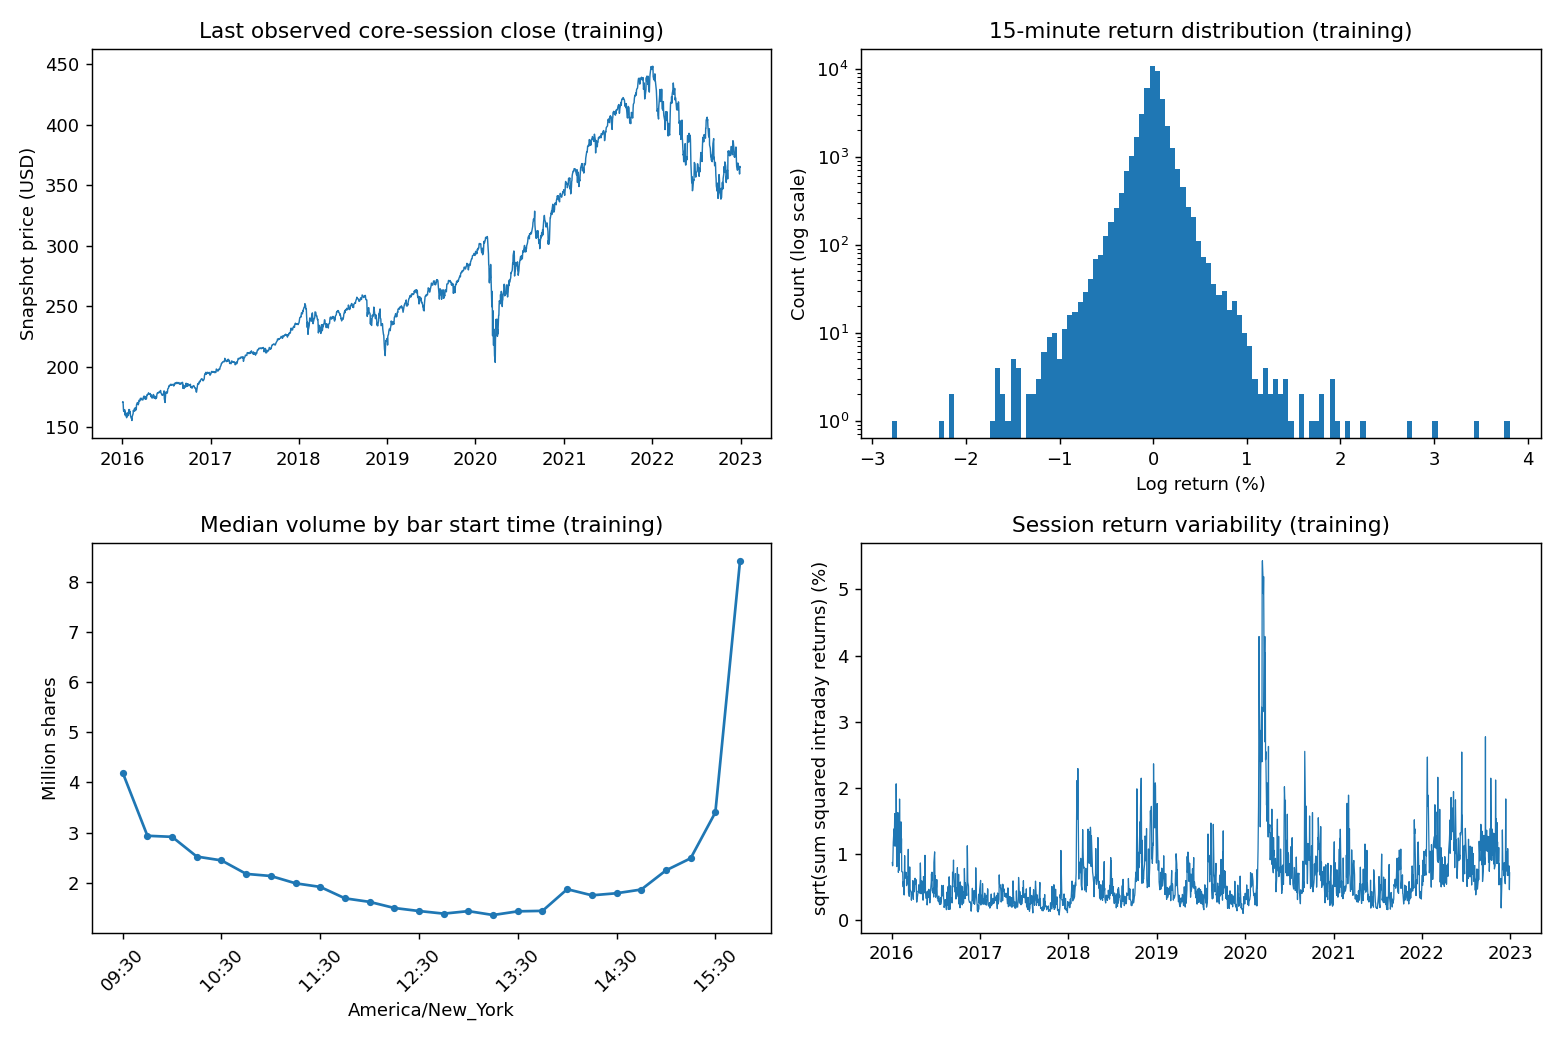

Lag-1 return correlation: 0.0086501579869642
Lag-1 squared-return correlation: 0.21454880220413003
Saved outputs: /Users/chenyaoleng/Downloads/SPY_CheckIn1_Simple/reports


In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
daily = train.groupby("session").close.last()
ax[0, 0].plot(pd.to_datetime(daily.index), daily.values, linewidth=0.8)
ax[0, 0].set(title="Last observed core-session close (training)", ylabel="Snapshot price (USD)")
ax[0, 1].hist(y * 100, bins=120, log=True)
ax[0, 1].set(title="15-minute return distribution (training)", xlabel="Log return (%)", ylabel="Count (log scale)")
volume = train.groupby(train.ts_et.dt.strftime("%H:%M")).volume.median()
ax[1, 0].plot(range(len(volume)), volume.values / 1e6, marker=".")
ax[1, 0].set_xticks(range(0, len(volume), 4), volume.index[::4], rotation=45)
ax[1, 0].set(title="Median volume by bar start time (training)", ylabel="Million shares", xlabel="America/New_York")
variability = train.groupby("session").target_return.apply(lambda x: np.sqrt((x.dropna() ** 2).sum()))
ax[1, 1].plot(pd.to_datetime(variability.index), variability.values * 100, linewidth=0.7)
ax[1, 1].set(title="Session return variability (training)", ylabel="sqrt(sum squared intraday returns) (%)")
fig.tight_layout()
fig.savefig(OUT / "eda_dashboard.png", dpi=130)
plt.close(fig)
display(Image(filename=str(OUT / "eda_dashboard.png")))


a = train.target_return
pair_ok = (train.session == train.session.shift(1)) & (train.ts_utc.diff() == pd.Timedelta(minutes=15))
pairs = pd.DataFrame({"current": a, "previous": a.shift(1)})[pair_ok].dropna()
print("Lag-1 return correlation:", pairs.current.corr(pairs.previous))
print("Lag-1 squared-return correlation:", (pairs.current ** 2).corr(pairs.previous ** 2))
print("Saved outputs:", OUT.resolve())


## Findings and next step
- The snapshot contains 169,241 raw bars and 69,973 calendar core-session bars through September 30, 2026. One expected core-session bar is missing. The `excluded` partition contains origins without a valid next-bar target, not a separate dataset split.
- Returns are heavy-tailed and variability changes over time. Weak return autocorrelation alongside stronger squared-return correlation motivates testing volatility features; it does not prove improved forecasting.
- Split by target timestamp: training 2016–2022, validation 2023–2024, final test 2025–September 2026. Eligible counts precede sequence/GARCH warm-up.
- Planned features: log differences `r[t] = log(P[t]) - log(P[t-1])`, GARCH conditional-variance forecasts, and standardized residuals. Log differencing can help with nonstationary price levels; stationarity tests and GARCH fits have not been performed here.
- Check-In 2: small market-feature LSTM versus GARCH-feature LSTM; zero-return and ridge baselines. Use return RMSE/MAE, identical forecast origins, and past-only feature fitting.
- Feed and adjustment are not confirmed by the supplied file. API access and market-data sharing permissions must be documented separately. This package contains the user-supplied snapshot for local use, not a grant to redistribute it publicly.